# Cross-Location Generalization Experiment
## Mamba Wind Speed Forecasting — Global Pooled & LOSO

**Experimental Design:**
- **Strategy 1 — Global Pooled**: Train ONE Mamba model on all 4 sites combined (with Site ID embedding). Test separately on each site's held-out test set.
- **Strategy 2 — LOSO (Leave-One-Site-Out)**: Train on 3 sites → test on the 4th. Rotate 4 times. Measures true zero-shot generalization to an unseen wind regime.

**Sites:**
| ID | Regime | File |
|---|---|---|
| 0 | Inland (A) | Site A - Inland.csv |
| 1 | Coastal (B) | Site B - Coastal.csv |
| 2 | Complex Terrain (C) | Site C - Complex Terrain.csv |
| 3 | Offshore (D) | Site D - Offshore.csv |

**Output:** Results tables ready for paper insertion.

## 0. Mount Drive & Install

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATA_DIR   = '/content/drive/MyDrive/wind_forecast/'
SAVE_DIR   = '/content/drive/MyDrive/wind_forecast/CrossLocation_Results/'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


## 1. Imports & Config

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import gc
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEQ_LEN    = 12       # lookback window (12 × 15min = 3 hours)
HORIZONS   = [2, 4, 8]  # steps ahead → 30, 60, 120 min
HOR_LABELS = ['30min', '60min', '120min']
BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE   = 10
N_SEEDS    = 5        # multiple runs for statistical stability

SITES = [
    {'id': 0, 'code': 'A', 'name': 'Inland',         'file': 'Site A - Inland.csv'},
    {'id': 1, 'code': 'B', 'name': 'Coastal',        'file': 'Site B - Coastal.csv'},
    {'id': 2, 'code': 'C', 'name': 'Complex Terrain','file': 'Site C - Complex Terrain.csv'},
    {'id': 3, 'code': 'D', 'name': 'Offshore',       'file': 'Site D - Offshore.csv'},
]
N_SITES = len(SITES)

FEATURE_COLS = [
    'temperature', 'pressure', 'hr_sin', 'hr_cos', 'month_sin', 'month_cos',
    'wind_sin', 'wind_cos', 'ws_lag_1', 'ws_lag_4', 'ws_lag_24',
    'dewpoint_temp', 'cloud_cover', 'precipitation', 'solar_radiation',
    'u_wind', 'v_wind', 'relative_humidity', 'air_density',
    'ws_rolling_mean_1h', 'ws_rolling_std_1h', 'ws_delta'
]
N_FEATURES = len(FEATURE_COLS)  # 22
print(f'Features: {N_FEATURES} | Sites: {N_SITES}')

Device: cuda
Features: 22 | Sites: 4


## 2. Mamba Model Architecture

In [ ]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, expand=2, d_conv=4, dropout=0.1):
        super().__init__()
        self.norm    = nn.LayerNorm(d_model)
        self.d_inner = expand * d_model
        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        self.conv1d  = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner
        )
        self.out_proj = nn.Linear(self.d_inner, d_model)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x        = self.norm(x)
        xz       = self.in_proj(x)
        x_inner, z = xz.chunk(2, dim=-1)
        x_inner  = self.conv1d(x_inner.transpose(1,2))[:, :, :x.shape[1]]
        x_inner  = F.silu(x_inner.transpose(1,2))
        z        = torch.sigmoid(z)
        out      = self.dropout(x_inner * z)
        return residual + self.out_proj(out)


class WindMamba(nn.Module):
    """
    Mamba with optional site-ID embedding for Global Pooled training.
    n_sites=0 → no embedding (Per-Site / LOSO mode)
    n_sites>0 → learnable site embedding concatenated to features
    """
    def __init__(self, input_size, d_model=64, num_layers=2, n_sites=0, site_emb_dim=4):
        super().__init__()
        self.use_site_emb = (n_sites > 0)
        if self.use_site_emb:
            self.site_emb  = nn.Embedding(n_sites, site_emb_dim)
            input_size_eff = input_size + site_emb_dim
        else:
            input_size_eff = input_size

        self.embed  = nn.Linear(input_size_eff, d_model)
        self.layers = nn.ModuleList([MambaBlock(d_model) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(d_model)
        self.fc     = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 3)
        )

    def forward(self, x, site_ids=None):
        if self.use_site_emb and site_ids is not None:
            emb = self.site_emb(site_ids)          # (B, emb_dim)
            emb = emb.unsqueeze(1).expand(-1, x.size(1), -1)  # (B, L, emb_dim)
            x   = torch.cat([x, emb], dim=-1)      # (B, L, feat+emb)
        x = self.embed(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.fc(x[:, -1, :])


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick sanity check
m = WindMamba(N_FEATURES, n_sites=N_SITES)
print(f'WindMamba (with site emb) params: {count_params(m):,}')
m2 = WindMamba(N_FEATURES, n_sites=0)
print(f'WindMamba (no  site emb) params: {count_params(m2):,}')

WindMamba (with site emb) params: 55,379
WindMamba (no  site emb) params: 55,107


## 3. Data Utilities

In [ ]:
def load_site_arrays(site_info, data_dir=DATA_DIR):
    """Load one site → returns (X_np float32, y_np float32, scaler_y)."""
    df = pd.read_csv(os.path.join(data_dir, site_info['file']))
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').dropna().reset_index(drop=True)

    n         = len(df)
    train_end = int(n * 0.70)

    X_raw = df[FEATURE_COLS].values.astype(np.float32)
    y_raw = df[['wind_speed']].values.astype(np.float32)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(X_raw[:train_end])
    scaler_y.fit(y_raw[:train_end])

    X_sc = scaler_X.transform(X_raw)
    y_sc = scaler_y.transform(y_raw)

    # sliding window
    max_hor = max(HORIZONS)
    X_wins, y_wins = [], []
    for i in range(len(X_sc) - SEQ_LEN - max_hor):
        X_wins.append(X_sc[i : i + SEQ_LEN])
        y_wins.append([y_sc[i + SEQ_LEN + h - 1][0] for h in HORIZONS])

    return (
        np.array(X_wins,  dtype=np.float32),
        np.array(y_wins,  dtype=np.float32),
        scaler_y
    )


def chrono_split(X, y, train_ratio=0.70, val_ratio=0.85):
    """Strict chronological 70/15/15 split."""
    n  = len(X)
    t1 = int(n * train_ratio)
    t2 = int(n * val_ratio)
    return (
        X[:t1],  y[:t1],
        X[t1:t2], y[t1:t2],
        X[t2:],   y[t2:]
    )


def to_loader(X, y, shuffle=False, site_id=None):
    Xt = torch.tensor(X)
    yt = torch.tensor(y)
    if site_id is not None:
        ids = torch.full((len(X),), site_id, dtype=torch.long)
        ds  = TensorDataset(Xt, yt, ids)
    else:
        ds  = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


def compute_metrics(y_true, y_pred):
    """Return dict of {horizon_label: {RMSE, MAE, R2}}."""
    results = {}
    for i, hl in enumerate(HOR_LABELS):
        yt, yp = y_true[:, i], y_pred[:, i]
        results[hl] = {
            'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
            'MAE' : float(mean_absolute_error(yt, yp)),
            'R2'  : float(r2_score(yt, yp)),
        }
    # overall
    results['Global'] = {
        'RMSE': float(np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))),
        'MAE' : float(mean_absolute_error(y_true.ravel(), y_pred.ravel())),
        'R2'  : float(r2_score(y_true.ravel(), y_pred.ravel())),
    }
    return results

print('Data utilities ready.')

Data utilities ready.


## 4. Training Engine

In [ ]:
def train_one_run(model, train_loader, val_loader, use_site_ids=False, label=''):
    """Train until early stopping. Returns best val loss and loss history."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )
    criterion = nn.MSELoss()

    best_loss   = float('inf')
    best_state  = None
    counter     = 0
    train_hist, val_hist = [], []
    t_start = time.time()

    for epoch in range(MAX_EPOCHS):
        model.train()
        tr_loss = 0.0
        for batch in train_loader:
            if use_site_ids:
                xb, yb, sid = [b.to(DEVICE) for b in batch]
                pred = model(xb, sid)
            else:
                xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)
                pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                if use_site_ids:
                    xb, yb, sid = [b.to(DEVICE) for b in batch]
                    pred = model(xb, sid)
                else:
                    xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)
                    pred = model(xb)
                vl_loss += criterion(pred, yb).item()
        vl_loss /= len(val_loader)

        scheduler.step(vl_loss)
        train_hist.append(tr_loss)
        val_hist.append(vl_loss)

        if vl_loss < best_loss:
            best_loss  = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter    = 0
        else:
            counter += 1

        if counter >= PATIENCE:
            break

    elapsed = time.time() - t_start
    if label:
        print(f'  [{label}] stopped @ epoch {epoch+1} | best_val={best_loss:.5f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    return elapsed, train_hist, val_hist


@torch.no_grad()
def evaluate(model, X_test, y_test_sc, scaler_y, use_site_ids=False, site_id=None):
    """Predict on test set → inverse transform → compute metrics."""
    model.eval()
    Xt = torch.tensor(X_test).to(DEVICE)
    if use_site_ids:
        ids  = torch.full((len(X_test),), site_id, dtype=torch.long).to(DEVICE)
        pred = model(Xt, ids).cpu().numpy()
    else:
        pred = model(Xt).cpu().numpy()

    y_pred = scaler_y.inverse_transform(pred)
    y_true = scaler_y.inverse_transform(y_test_sc)
    return compute_metrics(y_true, y_pred), y_true, y_pred


def measure_latency(model, sample_X, n_warmup=20, n_measure=200):
    """CPU latency in ms (batch=1)."""
    model_cpu = model.cpu().eval()
    x = torch.tensor(sample_X[:1])
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model_cpu(x)
        lats = []
        for _ in range(n_measure):
            t0 = time.perf_counter()
            _  = model_cpu(x)
            lats.append((time.perf_counter() - t0) * 1000)
    model.to(DEVICE)
    return float(np.mean(lats)), float(np.std(lats))

print('Training engine ready.')

Training engine ready.


## 5. Load All Site Data
Runs once — arrays cached in memory.

In [ ]:
site_data = []   # list of {X_all, y_all, scaler_y, train/val/test splits}

for s in SITES:
    X_all, y_all, scaler_y = load_site_arrays(s)
    X_tr, y_tr, X_va, y_va, X_te, y_te = chrono_split(X_all, y_all)
    site_data.append({
        'info'    : s,
        'X_all'   : X_all, 'y_all': y_all,
        'X_tr'    : X_tr,  'y_tr' : y_tr,
        'X_va'    : X_va,  'y_va' : y_va,
        'X_te'    : X_te,  'y_te' : y_te,
        'scaler_y': scaler_y,
    })
    print(f"Site {s['code']} ({s['name']}): "
          f"train={len(X_tr):,} | val={len(X_va):,} | test={len(X_te):,}")

print('\nAll sites loaded.')

Site A (Inland): train=73,618 | val=15,775 | test=15,776
Site B (Coastal): train=73,618 | val=15,775 | test=15,776
Site C (Complex Terrain): train=73,551 | val=15,761 | test=15,761
Site D (Offshore): train=73,618 | val=15,775 | test=15,776

All sites loaded.


## 6. Strategy 1 — Global Pooled Training
Train ONE model on all 4 sites (with site-ID embedding).
Evaluate on each site's test set to measure cross-regime coverage.

In [ ]:
def run_global_pooled(n_runs=N_SEEDS):
    print('\nStrategy 1: Global Pooled Training')
    all_run_metrics = []
    train_times     = []
    loss_histories  = []
    last_run_preds  = {}

    for run in range(n_runs):
        torch.manual_seed(run * 100 + SEED)
        np.random.seed(run * 100 + SEED)
        print(f'\n  Run {run+1}/{n_runs}')

        X_tr_list, y_tr_list, id_tr_list = [], [], []
        X_va_list, y_va_list, id_va_list = [], [], []
        for sd in site_data:
            sid = sd['info']['id']
            X_tr_list.append(sd['X_tr']);  y_tr_list.append(sd['y_tr'])
            X_va_list.append(sd['X_va']);  y_va_list.append(sd['y_va'])
            id_tr_list.append(np.full(len(sd['X_tr']), sid))
            id_va_list.append(np.full(len(sd['X_va']), sid))

        X_tr_pool = np.concatenate(X_tr_list)
        y_tr_pool = np.concatenate(y_tr_list)
        id_tr_pool = np.concatenate(id_tr_list).astype(np.int64)
        X_va_pool = np.concatenate(X_va_list)
        y_va_pool = np.concatenate(y_va_list)
        id_va_pool = np.concatenate(id_va_list).astype(np.int64)

        # Shuffle training pool
        perm = np.random.permutation(len(X_tr_pool))
        X_tr_pool, y_tr_pool, id_tr_pool = (
            X_tr_pool[perm], y_tr_pool[perm], id_tr_pool[perm]
        )

        Xt = torch.tensor(X_tr_pool)
        yt = torch.tensor(y_tr_pool)
        it = torch.tensor(id_tr_pool)
        train_loader = DataLoader(
            TensorDataset(Xt, yt, it), batch_size=BATCH_SIZE, shuffle=True
        )
        Xv = torch.tensor(X_va_pool)
        yv = torch.tensor(y_va_pool)
        iv = torch.tensor(id_va_pool)
        val_loader   = DataLoader(
            TensorDataset(Xv, yv, iv), batch_size=BATCH_SIZE, shuffle=False
        )

        # ── Train ──────────────────────────────────────────────────────────
        model = WindMamba(N_FEATURES, n_sites=N_SITES).to(DEVICE)
        t_elapsed, tr_hist, va_hist = train_one_run(
            model, train_loader, val_loader,
            use_site_ids=True, label=f'Global run{run+1}'
        )
        train_times.append(t_elapsed)
        loss_histories.append((tr_hist, va_hist))

        # ── Evaluate per site ──────────────────────────────────────────────
        run_metrics = {}
        for sd in site_data:
            sid   = sd['info']['id']
            code  = sd['info']['code']
            mets, y_true_s, y_pred_s = evaluate(
                model, sd['X_te'], sd['y_te'],
                sd['scaler_y'], use_site_ids=True, site_id=sid
            )
            run_metrics[code] = mets
            # Store last run's predictions for Figure 4
            if run == n_runs - 1:
                last_run_preds[code] = {'y_true': y_true_s, 'y_pred': y_pred_s}
        all_run_metrics.append(run_metrics)

        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()

    return all_run_metrics, train_times, loss_histories, last_run_preds


global_metrics, global_times, global_histories, global_pred_data = run_global_pooled()
print(f'\nGlobal Pooled avg training time: {np.mean(global_times):.1f}s ± {np.std(global_times):.1f}s')


Strategy 1: Global Pooled Training

  Run 1/5
  [Global run1] stopped @ epoch 24 | best_val=0.00048 | 651.0s

  Run 2/5
  [Global run2] stopped @ epoch 24 | best_val=0.00048 | 651.6s

  Run 3/5
  [Global run3] stopped @ epoch 34 | best_val=0.00049 | 926.0s

  Run 4/5
  [Global run4] stopped @ epoch 33 | best_val=0.00048 | 906.8s

  Run 5/5
  [Global run5] stopped @ epoch 28 | best_val=0.00047 | 765.6s

Global Pooled avg training time: 780.2s ± 119.0s


In [ ]:
import pickle, os
PRED_DIR = '/content/drive/MyDrive/wind_forecast/'
os.makedirs(PRED_DIR, exist_ok=True)

_save = {
    'global_metrics'   : global_metrics,
    'global_pred_data' : global_pred_data,
    'global_times'     : global_times,
}
with open(PRED_DIR + 'mamba_global_results.pkl', 'wb') as f:
    pickle.dump(_save, f)
with open('/content/mamba_global_results.pkl', 'wb') as f:
    pickle.dump(_save, f)

site_codes_sv = [s['code'] for s in SITES]
rmse_mamba_per_seed = {
    c: {h: [run[c][h]['RMSE'] for run in global_metrics] for h in HOR_LABELS}
    for c in site_codes_sv
}
import numpy as np
np.save(PRED_DIR + 'rmse_mamba_per_seed.npy', rmse_mamba_per_seed)
np.save('/content/rmse_mamba_per_seed.npy',   rmse_mamba_per_seed)

print(f"Saved → {PRED_DIR}mamba_global_results.pkl")
print(f"Saved → {PRED_DIR}rmse_mamba_per_seed.npy")
print(f"  global_metrics   : {len(global_metrics)} runs × {len(site_codes_sv)} sites")
print(f"  global_pred_data : sites = {list(global_pred_data.keys())}")

Saved → /content/drive/MyDrive/wind_forecast/mamba_global_results.pkl
Saved → /content/drive/MyDrive/wind_forecast/rmse_mamba_per_seed.npy
  global_metrics   : 5 runs × 4 sites
  global_pred_data : sites = ['A', 'B', 'C', 'D']


In [ ]:
print("TABLE 4 — Mamba (Global Pooled)  |  mean ± std, 5 seeds, averaged 4 sites")
print(f"  {'Horizon':<10}  {'RMSE':>18}  {'MAE':>18}  {'R2':>18}")
site_codes_list = [s['code'] for s in SITES]
for hor in HOR_LABELS:
    # Average across sites for each run, then mean/std across runs
    seed_rmse = [np.mean([run[c][hor]['RMSE'] for c in site_codes_list])
                 for run in global_metrics]
    seed_mae  = [np.mean([run[c][hor]['MAE']  for c in site_codes_list])
                 for run in global_metrics]
    seed_r2   = [np.mean([run[c][hor]['R2']   for c in site_codes_list])
                 for run in global_metrics]
    print(f"  {hor:<10}  {np.mean(seed_rmse):.4f} +/- {np.std(seed_rmse):.4f}"
          f"  {np.mean(seed_mae):.4f} +/- {np.std(seed_mae):.4f}"
          f"  {np.mean(seed_r2):.4f} +/- {np.std(seed_r2):.4f}")

print("TABLE 5 — Mamba (Global Pooled)  |  site-wise 30-min  (mean +/- std, 5 seeds)")
print(f"  {'Site':<28}  {'RMSE':>20}  {'R2':>20}")
for s in SITES:
    c    = s['code']
    name = s['name']
    rmses = [run[c]['30min']['RMSE'] for run in global_metrics]
    r2s   = [run[c]['30min']['R2']   for run in global_metrics]
    print(f"  {c} ({name:<22})  {np.mean(rmses):.4f} +/- {np.std(rmses):.4f}"
          f"  {np.mean(r2s):.4f} +/- {np.std(r2s):.4f}")

_mamba_bench = WindMamba(N_FEATURES, n_sites=N_SITES).to('cpu')
n_params_mamba   = count_params(_mamba_bench)
footprint_mb_m   = n_params_mamba * 4 / 1e6   # FP32 bytes -> MB

def _measure_latency_mamba(model, sample_X, n_warmup=20, n_measure=200):
    model_cpu = model.cpu().eval()
    x   = torch.tensor(sample_X[:1])          # shape (1, seq_len, n_features)
    sid = torch.zeros(1, dtype=torch.long)     # site_id = 0
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model_cpu(x, sid)
        lats = []
        for _ in range(n_measure):
            t0 = time.perf_counter()
            _  = model_cpu(x, sid)
            lats.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(lats)), float(np.std(lats))

_sample_X = site_data[0]['X_te']
lat_m_mamba, lat_s_mamba = _measure_latency_mamba(_mamba_bench, _sample_X)

# Global RMSE
global_rmse_mamba = float(np.mean([
    run[c][h]['RMSE']
    for run in global_metrics
    for c in site_codes_list
    for h in HOR_LABELS
]))
avg_train_s  = float(np.mean(global_times))
total_runs_h = len(global_times) * avg_train_s / 3600

print("TABLE 6 — Mamba  |  Model complexity & operational deployment")
print(f"  Parameters        : {n_params_mamba/1e3:.1f} K  ({n_params_mamba:,} params)")
print(f"  Model footprint   : ~{footprint_mb_m:.2f} MB  (FP32 weights)")
print(f"  Latency (CPU)     : {lat_m_mamba:.2f} +/- {lat_s_mamba:.2f} ms/sample  "
      f"(20 warm-up + 200 measure, batch=1)")
print(f"  Global RMSE       : {global_rmse_mamba:.4f}  (avg all sites x horizons x seeds)")
print(f"  Avg training time : {avg_train_s:.1f} s/run  ({avg_train_s/60:.1f} min/run)  "
      f"Total ~{total_runs_h:.1f} h ({len(global_times)} runs)")

TABLE 4 — Mamba (Global Pooled)  |  mean ± std, 5 seeds, averaged 4 sites
  Horizon                   RMSE                 MAE                  R2
  30min       0.1667 +/- 0.0027  0.1043 +/- 0.0039  0.9961 +/- 0.0001
  60min       0.3480 +/- 0.0019  0.2320 +/- 0.0030  0.9828 +/- 0.0002
  120min      0.6476 +/- 0.0022  0.4701 +/- 0.0015  0.9412 +/- 0.0005
TABLE 5 — Mamba (Global Pooled)  |  site-wise 30-min  (mean +/- std, 5 seeds)
  Site                                          RMSE                    R2
  A (Inland                )  0.1595 +/- 0.0037  0.9937 +/- 0.0003
  B (Coastal               )  0.1363 +/- 0.0038  0.9979 +/- 0.0001
  C (Complex Terrain       )  0.1919 +/- 0.0054  0.9950 +/- 0.0003
  D (Offshore              )  0.1793 +/- 0.0071  0.9981 +/- 0.0002
TABLE 6 — Mamba  |  Model complexity & operational deployment
  Parameters        : 55.4 K  (55,379 params)
  Model footprint   : ~0.22 MB  (FP32 weights)
  Latency (CPU)     : 1.08 +/- 0.10 ms/sample  (20 warm-up + 200 me

Loaded LSTM and Transformer predictions.


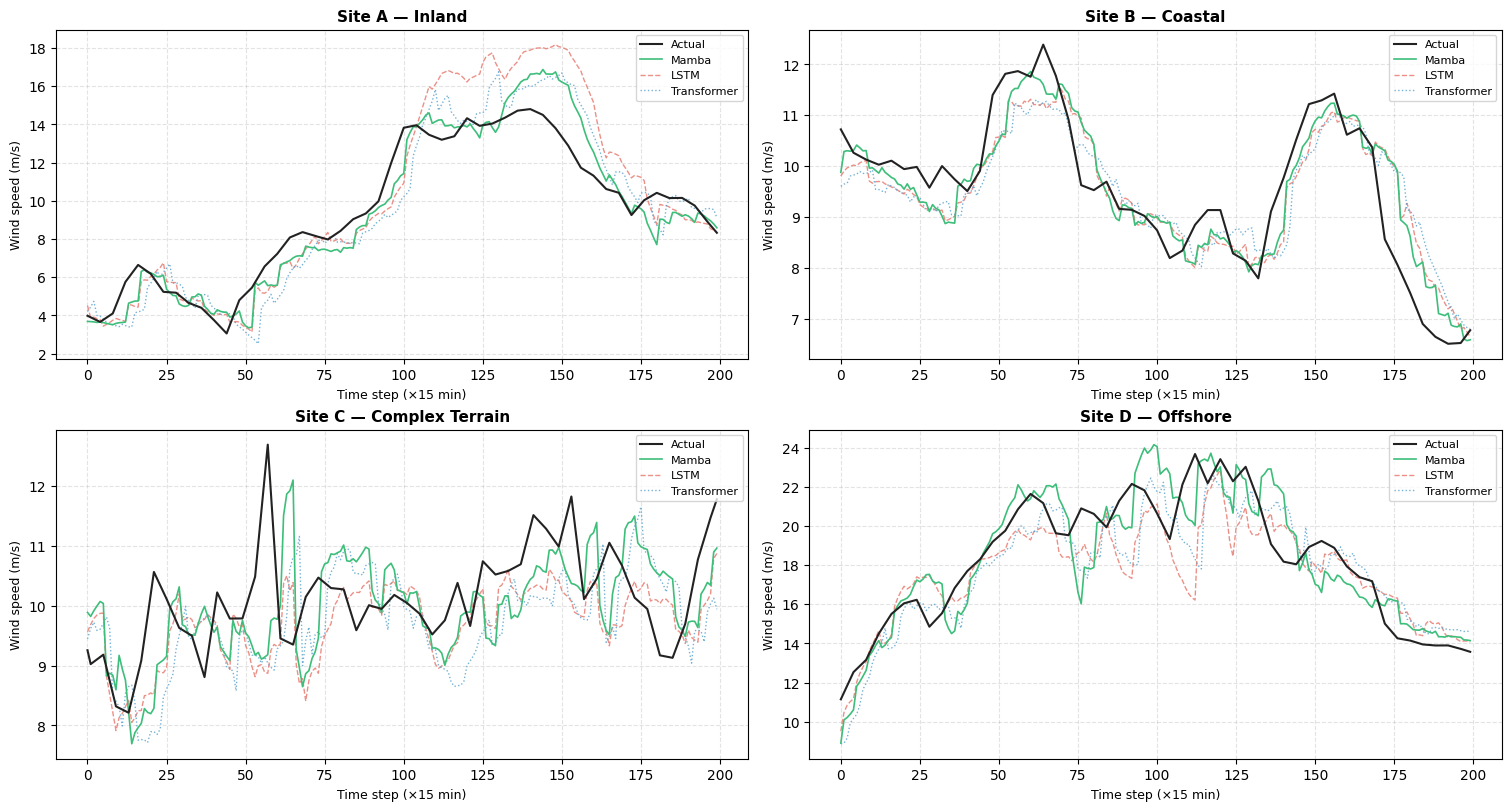

Saved: fig4_forecasting_trajectories_120min.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

PRED_DIR = '/content/drive/MyDrive/wind_forecast/'
try:
    preds_lstm_all        = np.load(PRED_DIR + 'preds_lstm.npy',        allow_pickle=True).item()
    preds_transformer_all = np.load(PRED_DIR + 'preds_transformer.npy', allow_pickle=True).item()
    print("Loaded LSTM and Transformer predictions.")
except FileNotFoundError:
    print("[WARNING] LSTM/Transformer prediction files not found.")
    print("  Run the LSTM+Transformer notebook first and save preds to PRED_DIR.")
    preds_lstm_all = preds_transformer_all = None

SITE_KEYS = {
    'A': 'Site A - Inland',
    'B': 'Site B - Coastal',
    'C': 'Site C - Complex Terrain',
    'D': 'Site D - Offshore',
}
SITE_LABELS = {
    'A': 'Site A — Inland',
    'B': 'Site B — Coastal',
    'C': 'Site C — Complex Terrain',
    'D': 'Site D — Offshore',
}
WINDOW   = 200   # how many test-set steps to display
HOR_IDX  = 2     # column index for 120-min horizon
COLORS   = {'Actual': '#222222', 'LSTM': '#E87D72', 'Transformer': '#5BA4CF', 'Mamba': '#3DBE7A'}

fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)

for ax, (code, site_key) in zip(axes.flat, SITE_KEYS.items()):
    sd = next(s for s in site_data if s['info']['code'] == code)

    y_true_m = global_pred_data[code]['y_true'][:WINDOW, HOR_IDX]
    y_pred_m = global_pred_data[code]['y_pred'][:WINDOW, HOR_IDX]

    x = np.arange(WINDOW)
    ax.plot(x, y_true_m, color=COLORS['Actual'], lw=1.5, label='Actual', zorder=4)
    ax.plot(x, y_pred_m, color=COLORS['Mamba'],  lw=1.2, label='Mamba',  zorder=3, ls='-')

    if preds_lstm_all and site_key in preds_lstm_all:
        y_pred_l = preds_lstm_all[site_key]['y_pred'][:WINDOW, HOR_IDX]
        ax.plot(x, y_pred_l, color=COLORS['LSTM'],        lw=1.0, label='LSTM',
                ls='--', alpha=0.85, zorder=2)

    if preds_transformer_all and site_key in preds_transformer_all:
        y_pred_t = preds_transformer_all[site_key]['y_pred'][:WINDOW, HOR_IDX]
        ax.plot(x, y_pred_t, color=COLORS['Transformer'], lw=1.0, label='Transformer',
                ls=':', alpha=0.85, zorder=2)

    ax.set_title(SITE_LABELS[code], fontsize=11, fontweight='bold')
    ax.set_xlabel('Time step (×15 min)', fontsize=9)
    ax.set_ylabel('Wind speed (m/s)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.35)

plt.savefig(PRED_DIR + 'fig4_forecasting_trajectories_120min.png',
            dpi=600, bbox_inches='tight')
plt.savefig('/content/fig4_forecasting_trajectories_120min.png',
            dpi=600, bbox_inches='tight')
plt.show()
print("Saved: fig4_forecasting_trajectories_120min.png")

  Loaded rmse_rf_per_seed.npy
  Loaded rmse_lstm_per_seed.npy
  Loaded rmse_trans_per_seed.npy


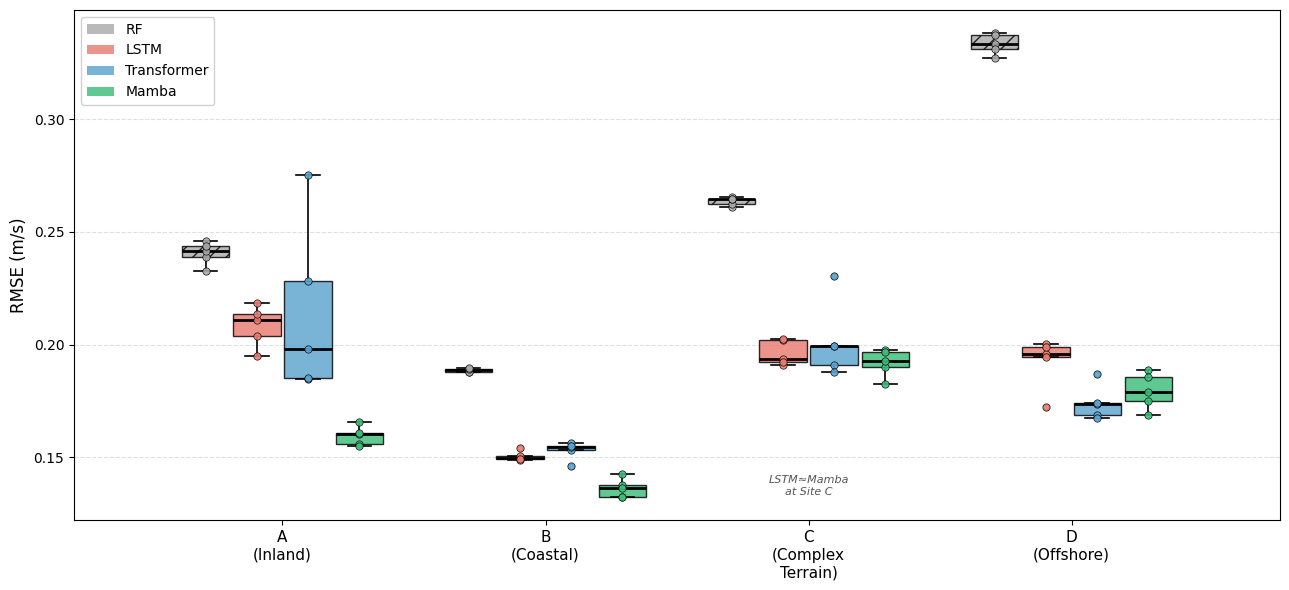

Saved: fig5_boxplot_rmse_30min.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PRED_DIR = '/content/drive/MyDrive/wind_forecast/'

def _load_npy(fname):
    for path in [f'/content/{fname}', PRED_DIR + fname]:
        if os.path.exists(path):
            print(f"  Loaded {fname}")
            return np.load(path, allow_pickle=True).item()
    print(f"  [MISSING] {fname} — run corresponding notebook first")
    return None

rmse_rf    = _load_npy('rmse_rf_per_seed.npy')
rmse_lstm  = _load_npy('rmse_lstm_per_seed.npy')
rmse_trans = _load_npy('rmse_trans_per_seed.npy')

SITE_CODE_MAP = {
    'Site A - Inland':          'A',
    'Site B - Coastal':         'B',
    'Site C - Complex Terrain': 'C',
    'Site D - Offshore':        'D',
}

def normalize_keys(d):
    if d is None:
        return None
    first_key = next(iter(d))
    if first_key in SITE_CODE_MAP:          # key dài → remap
        return {SITE_CODE_MAP[k]: v for k, v in d.items()}
    return d                                # key ngắn → giữ nguyên

rmse_rf    = normalize_keys(rmse_rf)
rmse_lstm  = normalize_keys(rmse_lstm)
rmse_trans = normalize_keys(rmse_trans)

# ── Build Mamba per-seed RMSE from global_metrics ────────────────────────────
rmse_mamba = {}
for s in SITES:
    c = s['code']
    rmse_mamba[c] = {}
    for hor in HOR_LABELS:
        rmse_mamba[c][hor] = [run[c][hor]['RMSE'] for run in global_metrics]

HORIZON   = '30min'
SITES_ORD = ['A', 'B', 'C', 'D']
SITE_LBLS = ['A\n(Inland)', 'B\n(Coastal)', 'C\n(Complex\nTerrain)', 'D\n(Offshore)']

MODEL_CFG = [
    ('RF',          rmse_rf,    '#AAAAAA', '//'),
    ('LSTM',        rmse_lstm,  '#E87D72', ''),
    ('Transformer', rmse_trans, '#5BA4CF', ''),
    ('Mamba',       rmse_mamba, '#3DBE7A', ''),
]
N_MODELS = len(MODEL_CFG)
N_SITES_PLOT = len(SITES_ORD)
WIDTH = 0.18
GAP   = 0.06

fig, ax = plt.subplots(figsize=(13, 6))

for m_idx, (name, rmse_dict, color, hatch) in enumerate(MODEL_CFG):
    if rmse_dict is None:
        continue
    positions = [i + (m_idx - N_MODELS/2 + 0.5) * (WIDTH + GAP/N_MODELS)
                 for i in range(N_SITES_PLOT)]
    data = [rmse_dict[c][HORIZON] for c in SITES_ORD]
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=WIDTH,
        patch_artist=True,
        notch=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.6),
        boxprops=dict(facecolor=color, alpha=0.82, hatch=hatch),
    )
    for pos, vals in zip(positions, data):
        ax.scatter([pos]*len(vals), vals, color=color, edgecolors='black',
                   s=28, zorder=5, linewidths=0.5, alpha=0.9)

ax.set_xticks(range(N_SITES_PLOT))
ax.set_xticklabels(SITE_LBLS, fontsize=11)
ax.set_ylabel('RMSE (m/s)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

legend_patches = [
    mpatches.Patch(facecolor=c, label=n, alpha=0.82)
    for n, _, c, _ in MODEL_CFG if _ is not None
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10,
          framealpha=0.9, edgecolor='#cccccc')

ax.annotate(
    'LSTM≈Mamba\nat Site C',
    xy=(2, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.05),
    fontsize=8, color='#555555', ha='center', style='italic'
)

plt.tight_layout()
plt.savefig(PRED_DIR + f'fig5_boxplot_rmse_{HORIZON}.png', dpi=200, bbox_inches='tight')
plt.savefig(f'/content/fig5_boxplot_rmse_{HORIZON}.png',  dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: fig5_boxplot_rmse_{HORIZON}.png")

## 7. Strategy 2 — LOSO (Leave-One-Site-Out)
For each fold k: train on sites ≠ k → test on site k.  
Measures **zero-shot generalization** to unseen wind regimes.

In [ ]:
def run_loso(n_runs=N_SEEDS):
    print('\n=== Strategy 2: LOSO Cross-Validation ===')
    loso_results = {}  # {site_code: list of metric dicts (one per run)}
    loso_times   = {}  # {site_code: list of train times}
    loso_histories = {} # {site_code: list of (tr_hist, val_hist)}

    for test_idx in range(N_SITES):
        test_sd   = site_data[test_idx]
        test_code = test_sd['info']['code']
        train_sds = [sd for i, sd in enumerate(site_data) if i != test_idx]
        train_codes = [sd['info']['code'] for sd in train_sds]

        print(f"\n--- Fold: test={test_code} | train={train_codes} ---")
        loso_results[test_code]   = []
        loso_times[test_code]     = []
        loso_histories[test_code] = []

        for run in range(n_runs):
            torch.manual_seed(run * 100 + SEED)
            np.random.seed(run * 100 + SEED)

            # ── Pool training sites (no site embedding in LOSO) ────────────
            # We use n_sites=0: model sees only features, no ID hint
            # This is the hardest / most honest generalization test
            X_tr_list, y_tr_list = [], []
            X_va_list, y_va_list = [], []
            for sd in train_sds:
                X_tr_list.append(sd['X_tr']); y_tr_list.append(sd['y_tr'])
                X_va_list.append(sd['X_va']); y_va_list.append(sd['y_va'])

            X_tr = np.concatenate(X_tr_list)
            y_tr = np.concatenate(y_tr_list)
            X_va = np.concatenate(X_va_list)
            y_va = np.concatenate(y_va_list)

            perm = np.random.permutation(len(X_tr))
            X_tr, y_tr = X_tr[perm], y_tr[perm]

            train_loader = DataLoader(
                TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
                batch_size=BATCH_SIZE, shuffle=True
            )
            val_loader = DataLoader(
                TensorDataset(torch.tensor(X_va), torch.tensor(y_va)),
                batch_size=BATCH_SIZE, shuffle=False
            )

            # ── Train ──────────────────────────────────────────────────────
            model = WindMamba(N_FEATURES, n_sites=0).to(DEVICE)
            t_elapsed, tr_hist, va_hist = train_one_run(
                model, train_loader, val_loader,
                use_site_ids=False,
                label=f'LOSO test={test_code} run{run+1}'
            )
            loso_times[test_code].append(t_elapsed)
            loso_histories[test_code].append((tr_hist, va_hist))

            # ── Evaluate on held-out test site ─────────────────────────────
            mets, _, _ = evaluate(
                model, test_sd['X_te'], test_sd['y_te'],
                test_sd['scaler_y'], use_site_ids=False
            )
            loso_results[test_code].append(mets)

            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
            gc.collect()

        avg_rmse = np.mean([
            m['Global']['RMSE'] for m in loso_results[test_code]
        ])
        print(f"  Site {test_code} avg Global RMSE = {avg_rmse:.4f}")

    return loso_results, loso_times, loso_histories


loso_metrics, loso_times, loso_histories = run_loso()
print('\nLOSO complete.')


=== Strategy 2: LOSO Cross-Validation ===

--- Fold: test=A | train=['B', 'C', 'D'] ---
  [LOSO test=A run1] stopped @ epoch 31 | best_val=0.00051 | 578.1s
  [LOSO test=A run2] stopped @ epoch 28 | best_val=0.00051 | 522.3s
  [LOSO test=A run3] stopped @ epoch 27 | best_val=0.00049 | 501.5s
  [LOSO test=A run4] stopped @ epoch 39 | best_val=0.00050 | 716.5s
  [LOSO test=A run5] stopped @ epoch 32 | best_val=0.00050 | 592.8s
  Site A avg Global RMSE = 0.6678

--- Fold: test=B | train=['A', 'C', 'D'] ---
  [LOSO test=B run1] stopped @ epoch 25 | best_val=0.00051 | 464.1s
  [LOSO test=B run2] stopped @ epoch 33 | best_val=0.00051 | 615.5s
  [LOSO test=B run3] stopped @ epoch 35 | best_val=0.00051 | 646.0s
  [LOSO test=B run4] stopped @ epoch 32 | best_val=0.00051 | 590.7s
  [LOSO test=B run5] stopped @ epoch 29 | best_val=0.00052 | 537.2s
  Site B avg Global RMSE = 0.4821

--- Fold: test=C | train=['A', 'B', 'D'] ---
  [LOSO test=C run1] stopped @ epoch 42 | best_val=0.00038 | 783.2s
  [

In [ ]:
import pickle, os
PRED_DIR = '/content/drive/MyDrive/wind_forecast/'
os.makedirs(PRED_DIR, exist_ok=True)

_save_loso = {
    'loso_metrics'   : loso_metrics,
    'loso_times'     : loso_times,
    'loso_histories' : loso_histories,
}
with open(PRED_DIR + 'mamba_loso_results.pkl', 'wb') as f:
    pickle.dump(_save_loso, f)
with open('/content/mamba_loso_results.pkl', 'wb') as f:
    pickle.dump(_save_loso, f)

print(f"Saved → {PRED_DIR}mamba_loso_results.pkl")
print(f"LOSO sites saved: {list(loso_metrics.keys())}")

Saved → /content/drive/MyDrive/wind_forecast/mamba_loso_results.pkl
LOSO sites saved: ['A', 'B', 'C', 'D']


## 8. Results Aggregation & Paper-Ready Tables

In [ ]:
def aggregate_runs(list_of_dicts):
    """
    Input: list of {site_code: {horizon: {metric: val}}} dicts (one per run)
    Output: same shape but values are (mean, std) tuples
    """
    result = {}
    site_codes = list(list_of_dicts[0].keys())
    for code in site_codes:
        result[code] = {}
        horizons = list(list_of_dicts[0][code].keys())
        for hor in horizons:
            result[code][hor] = {}
            metrics = list(list_of_dicts[0][code][hor].keys())
            for met in metrics:
                vals = [d[code][hor][met] for d in list_of_dicts]
                result[code][hor][met] = (np.mean(vals), np.std(vals))
    return result


def agg_loso(loso_results_dict):
    """
    loso_results_dict: {site_code: [list of {hor: {met: val}} per run]}
    Returns same as aggregate_runs but keyed directly by site_code
    """
    result = {}
    for code, runs in loso_results_dict.items():
        result_c = {}
        horizons = list(runs[0].keys())
        for hor in horizons:
            result_c[hor] = {}
            metrics = list(runs[0][hor].keys())
            for met in metrics:
                vals = [r[hor][met] for r in runs]
                result_c[hor][met] = (np.mean(vals), np.std(vals))
        result[code] = result_c
    return result


global_agg = aggregate_runs(global_metrics)
loso_agg   = agg_loso(loso_metrics)

# ─── Build flat DataFrame for paper Table ───────────────────────────────────
rows = []
for s in SITES:
    code = s['code']
    name = s['name']
    for hor in HOR_LABELS:
        g_rmse_m, g_rmse_s = global_agg[code][hor]['RMSE']
        g_mae_m,  g_mae_s  = global_agg[code][hor]['MAE']
        g_r2_m,   g_r2_s   = global_agg[code][hor]['R2']
        l_rmse_m, l_rmse_s = loso_agg[code][hor]['RMSE']
        l_mae_m,  l_mae_s  = loso_agg[code][hor]['MAE']
        l_r2_m,   l_r2_s   = loso_agg[code][hor]['R2']
        rows.append({
            'Site'  : f"{code} ({name})",
            'Horizon': hor,
            'Global_RMSE' : f"{g_rmse_m:.4f} ± {g_rmse_s:.4f}",
            'Global_MAE'  : f"{g_mae_m:.4f} ± {g_mae_s:.4f}",
            'Global_R2'   : f"{g_r2_m:.4f} ± {g_r2_s:.4f}",
            'LOSO_RMSE'   : f"{l_rmse_m:.4f} ± {l_rmse_s:.4f}",
            'LOSO_MAE'    : f"{l_mae_m:.4f} ± {l_mae_s:.4f}",
            'LOSO_R2'     : f"{l_r2_m:.4f} ± {l_r2_s:.4f}",
            # raw means for sorting/coloring
            '_g_rmse': g_rmse_m, '_l_rmse': l_rmse_m,
            '_g_r2'  : g_r2_m,   '_l_r2'  : l_r2_m,
        })

df_results = pd.DataFrame(rows)

print('TABLE: Cross-Location Generalization — Mamba (mean ± std over 5 seeds)')
print(df_results[[
    'Site','Horizon',
    'Global_RMSE','Global_MAE','Global_R2',
    'LOSO_RMSE','LOSO_MAE','LOSO_R2'
]].to_string(index=False))

# Save
df_results.to_csv(os.path.join(SAVE_DIR, 'cross_location_results.csv'), index=False)
print(f'\nSaved → {SAVE_DIR}cross_location_results.csv')

TABLE: Cross-Location Generalization — Mamba (mean ± std over 5 seeds)
               Site Horizon     Global_RMSE      Global_MAE       Global_R2       LOSO_RMSE        LOSO_MAE         LOSO_R2
         A (Inland)   30min 0.1595 ± 0.0037 0.1023 ± 0.0065 0.9937 ± 0.0003 0.3458 ± 0.0447 0.2775 ± 0.0457 0.9697 ± 0.0080
         A (Inland)   60min 0.3499 ± 0.0024 0.2342 ± 0.0032 0.9695 ± 0.0004 0.5572 ± 0.0345 0.4131 ± 0.0350 0.9224 ± 0.0097
         A (Inland)  120min 0.6572 ± 0.0048 0.4828 ± 0.0039 0.8925 ± 0.0016 0.9521 ± 0.0367 0.7122 ± 0.0307 0.7740 ± 0.0175
        B (Coastal)   30min 0.1363 ± 0.0038 0.0895 ± 0.0044 0.9979 ± 0.0001 0.2205 ± 0.0171 0.1722 ± 0.0182 0.9944 ± 0.0008
        B (Coastal)   60min 0.2974 ± 0.0036 0.2056 ± 0.0027 0.9899 ± 0.0002 0.3794 ± 0.0086 0.2830 ± 0.0086 0.9835 ± 0.0007
        B (Coastal)  120min 0.5485 ± 0.0055 0.4121 ± 0.0026 0.9656 ± 0.0007 0.7102 ± 0.0129 0.5447 ± 0.0110 0.9423 ± 0.0021
C (Complex Terrain)   30min 0.1919 ± 0.0054 0.1117 ± 0.0036 0

## 9. Summary Table — Averaged Across All Sites

In [ ]:
summary_rows = []
for hor in HOR_LABELS:
    sub = df_results[df_results['Horizon'] == hor]
    summary_rows.append({
        'Horizon'         : hor,
        'Global_RMSE_avg' : sub['_g_rmse'].mean(),
        'LOSO_RMSE_avg'   : sub['_l_rmse'].mean(),
        'Global_R2_avg'   : sub['_g_r2'].mean(),
        'LOSO_R2_avg'     : sub['_l_r2'].mean(),
        'RMSE_gap'        : sub['_l_rmse'].mean() - sub['_g_rmse'].mean(),  # LOSO degradation
    })

df_summary = pd.DataFrame(summary_rows)
print('\nSummary (averaged over 4 sites):')
print(df_summary.round(4).to_string(index=False))
print()
print('RMSE_gap = LOSO - Global (smaller = better generalization, ideally < 0.05)')

df_summary.to_csv(os.path.join(SAVE_DIR, 'cross_location_summary.csv'), index=False)
print(f'Saved: {SAVE_DIR}cross_location_summary.csv')


Summary (averaged over 4 sites):
Horizon  Global_RMSE_avg  LOSO_RMSE_avg  Global_R2_avg  LOSO_R2_avg  RMSE_gap
  30min           0.1667         0.3022         0.9961       0.9865    0.1355
  60min           0.3480         0.5148         0.9828       0.9625    0.1668
 120min           0.6476         0.9530         0.9412       0.8789    0.3054

RMSE_gap = LOSO - Global (smaller = better generalization, ideally < 0.05)
Saved: /content/drive/MyDrive/wind_forecast/CrossLocation_Results/cross_location_summary.csv


## 10. Visualizations

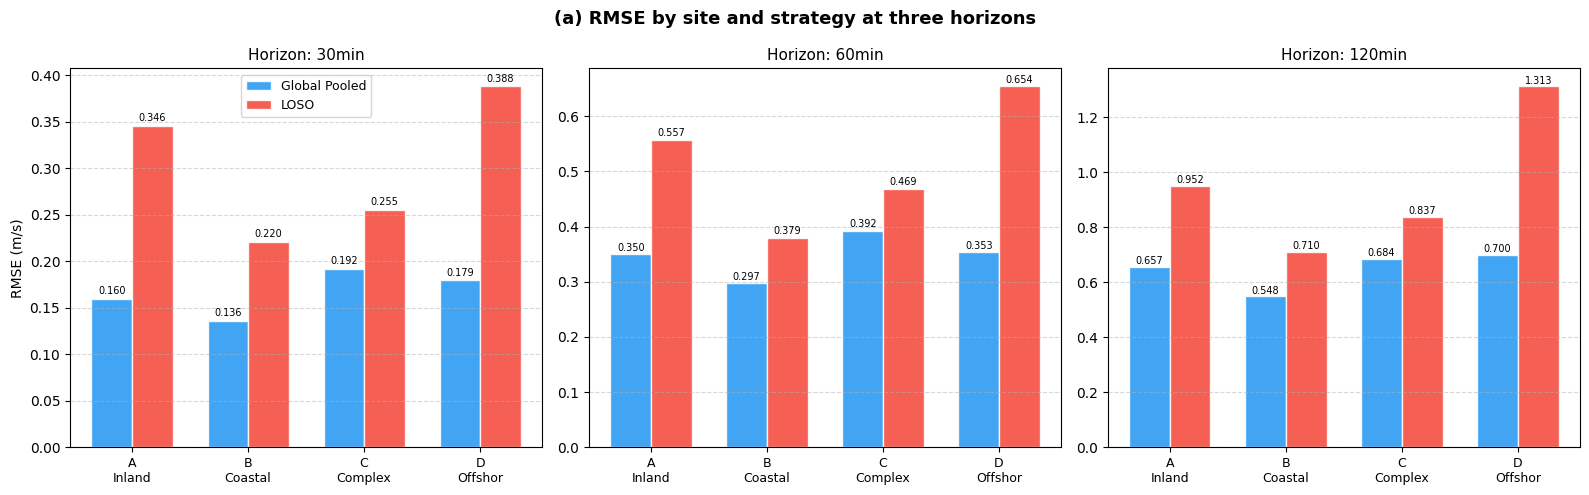

Saved: fig_generalization_rmse_bar.png


In [ ]:
site_labels  = [s['code'] + '\n' + s['name'][:7] for s in SITES]
site_codes   = [s['code'] for s in SITES]
colors_g     = ['#2196F3', '#42A5F5', '#90CAF9']   # blues = Global
colors_l     = ['#F44336', '#EF9A9A', '#FFCDD2']   # reds  = LOSO

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('(a) RMSE by site and strategy at three horizons',
             fontsize=13, fontweight='bold')

for ax_i, hor in enumerate(HOR_LABELS):
    ax = axes[ax_i]
    sub = df_results[df_results['Horizon'] == hor].reset_index(drop=True)
    x   = np.arange(N_SITES)
    w   = 0.35
    b1  = ax.bar(x - w/2, sub['_g_rmse'], w,
                 label='Global Pooled', color='#2196F3', alpha=0.85, edgecolor='white')
    b2  = ax.bar(x + w/2, sub['_l_rmse'], w,
                 label='LOSO',         color='#F44336', alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(site_labels, fontsize=9)
    ax.set_title(f'Horizon: {hor}', fontsize=11)
    ax.set_ylabel('RMSE (m/s)' if ax_i == 0 else '')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    if ax_i == 0:
        ax.legend(fontsize=9)
    # value labels
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_generalization_rmse_bar.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: fig_generalization_rmse_bar.png')

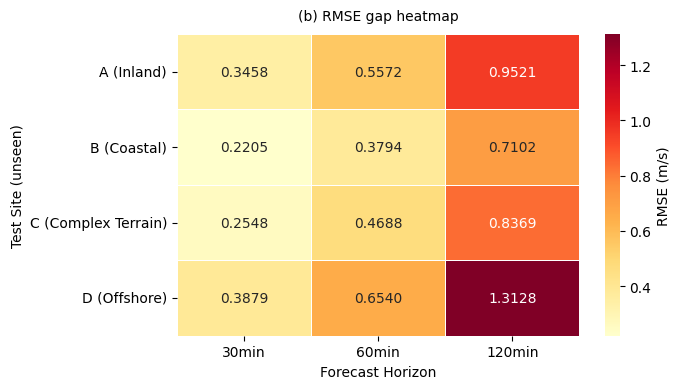

Saved: fig_loso_heatmap.png


In [ ]:
# ── Figure 2: Heatmap — LOSO RMSE matrix (test site × horizon) ──────────────
heatmap_data = np.array([
    [loso_agg[c][h]['RMSE'][0] for h in HOR_LABELS]
    for c in site_codes
])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
    xticklabels=HOR_LABELS,
    yticklabels=[f"{s['code']} ({s['name']})" for s in SITES],
    ax=ax, linewidths=0.5, cbar_kws={'label': 'RMSE (m/s)'}
)
ax.set_title('(b) RMSE gap heatmap',
             fontsize=10, pad=10)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Test Site (unseen)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_loso_heatmap.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved: fig_loso_heatmap.png')

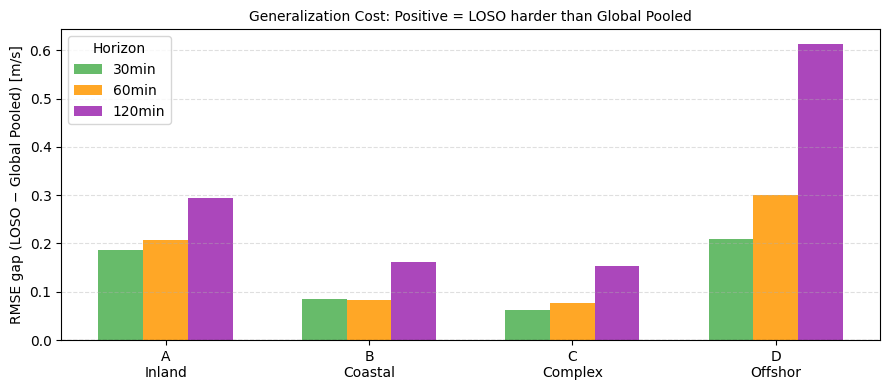

Saved: fig_generalization_gap.png


In [ ]:
# ── Figure 3: RMSE gap bar (LOSO - Global) — generalization cost ─────────────
gap_data = np.array([
    [
        loso_agg[c][h]['RMSE'][0] - global_agg[c][h]['RMSE'][0]
        for h in HOR_LABELS
    ]
    for c in site_codes
])

x    = np.arange(N_SITES)
w    = 0.22
colors_h = ['#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 4))
for i, (hor, col) in enumerate(zip(HOR_LABELS, colors_h)):
    ax.bar(x + (i - 1) * w, gap_data[:, i], w, label=hor, color=col, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(site_labels)
ax.set_ylabel('RMSE gap (LOSO − Global Pooled) [m/s]')
ax.set_title('Generalization Cost: Positive = LOSO harder than Global Pooled', fontsize=10)
ax.legend(title='Horizon')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_generalization_gap.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_generalization_gap.png')

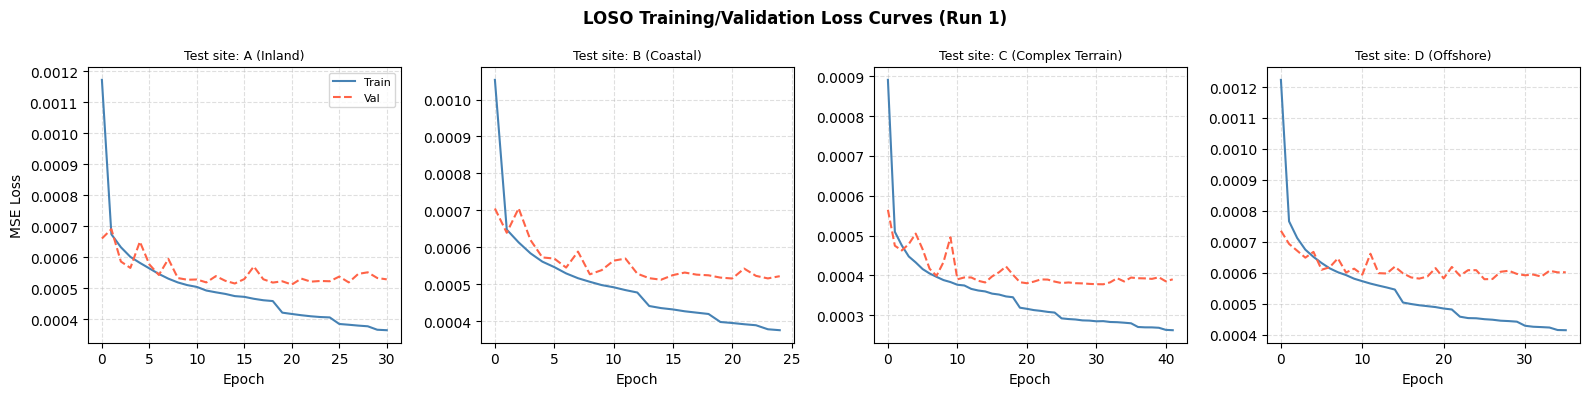

Saved: fig_loso_loss_curves.png


In [ ]:
# ── Figure 4: Loss curves (one representative run per LOSO fold) ──────────────
fig, axes = plt.subplots(1, N_SITES, figsize=(16, 4), sharey=False)
fig.suptitle('LOSO Training/Validation Loss Curves (Run 1)', fontsize=12, fontweight='bold')

for ax_i, s in enumerate(SITES):
    code = s['code']
    tr_hist, va_hist = loso_histories[code][0]  # run 1
    ax = axes[ax_i]
    ax.plot(tr_hist, label='Train', color='steelblue', linewidth=1.5)
    ax.plot(va_hist, label='Val',   color='tomato',    linewidth=1.5, linestyle='--')
    ax.set_title(f'Test site: {code} ({s["name"]})', fontsize=9)
    ax.set_xlabel('Epoch')
    if ax_i == 0:
        ax.set_ylabel('MSE Loss')
        ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig_loso_loss_curves.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: fig_loso_loss_curves.png')

## 12. Key Numbers for Paper Narrative
Auto-generated sentences to copy into Section 3.

In [ ]:
print('=== AUTO-GENERATED NARRATIVE NUMBERS ===')
print()

# Best/worst LOSO site
loso_global_rmse = {c: loso_agg[c]['Global']['RMSE'][0] for c in site_codes}
best_site  = min(loso_global_rmse, key=loso_global_rmse.get)
worst_site = max(loso_global_rmse, key=loso_global_rmse.get)
best_name  = next(s['name'] for s in SITES if s['code'] == best_site)
worst_name = next(s['name'] for s in SITES if s['code'] == worst_site)

# Average degradation
avg_gap_120 = np.mean([
    loso_agg[c]['120min']['RMSE'][0] - global_agg[c]['120min']['RMSE'][0]
    for c in site_codes
])

print(f"[1] Best LOSO generalization: Site {best_site} ({best_name}), "
      f"Global RMSE = {loso_global_rmse[best_site]:.4f}")
print(f"[2] Hardest LOSO site: Site {worst_site} ({worst_name}), "
      f"Global RMSE = {loso_global_rmse[worst_site]:.4f}")
print(f"[3] Average RMSE gap at 120-min (LOSO − Global): {avg_gap_120:+.4f} m/s")
print(f"[4] Global Pooled avg train time: {np.mean(global_times):.1f}s")
print()

# LOSO R2 at 120 min
for c in site_codes:
    name = next(s['name'] for s in SITES if s['code'] == c)
    r2_l = loso_agg[c]['120min']['R2'][0]
    r2_g = global_agg[c]['120min']['R2'][0]
    print(f"  Site {c} ({name}): LOSO R² (120min) = {r2_l:.4f} | "
          f"Global R² (120min) = {r2_g:.4f}")

print()
print('Interpretation guide:')
print('  RMSE_gap ≈ 0     → Global Pooled and LOSO are equivalent (strong generalization)')
print('  RMSE_gap < 0.05  → Acceptable generalization with minor degradation')
print('  RMSE_gap > 0.10  → Significant domain gap; site-specific fine-tuning recommended')

=== AUTO-GENERATED NARRATIVE NUMBERS ===

[1] Best LOSO generalization: Site B (Coastal), Global RMSE = 0.4821
[2] Hardest LOSO site: Site D (Offshore), Global RMSE = 0.8765
[3] Average RMSE gap at 120-min (LOSO − Global): +0.3054 m/s
[4] Global Pooled avg train time: 780.2s

  Site A (Inland): LOSO R² (120min) = 0.7740 | Global R² (120min) = 0.8925
  Site B (Coastal): LOSO R² (120min) = 0.9423 | Global R² (120min) = 0.9656
  Site C (Complex Terrain): LOSO R² (120min) = 0.9044 | Global R² (120min) = 0.9361
  Site D (Offshore): LOSO R² (120min) = 0.8949 | Global R² (120min) = 0.9705

Interpretation guide:
  RMSE_gap ≈ 0     → Global Pooled and LOSO are equivalent (strong generalization)
  RMSE_gap < 0.05  → Acceptable generalization with minor degradation
  RMSE_gap > 0.10  → Significant domain gap; site-specific fine-tuning recommended
